Total unique (X, Y) coordinate pairs found: 280653


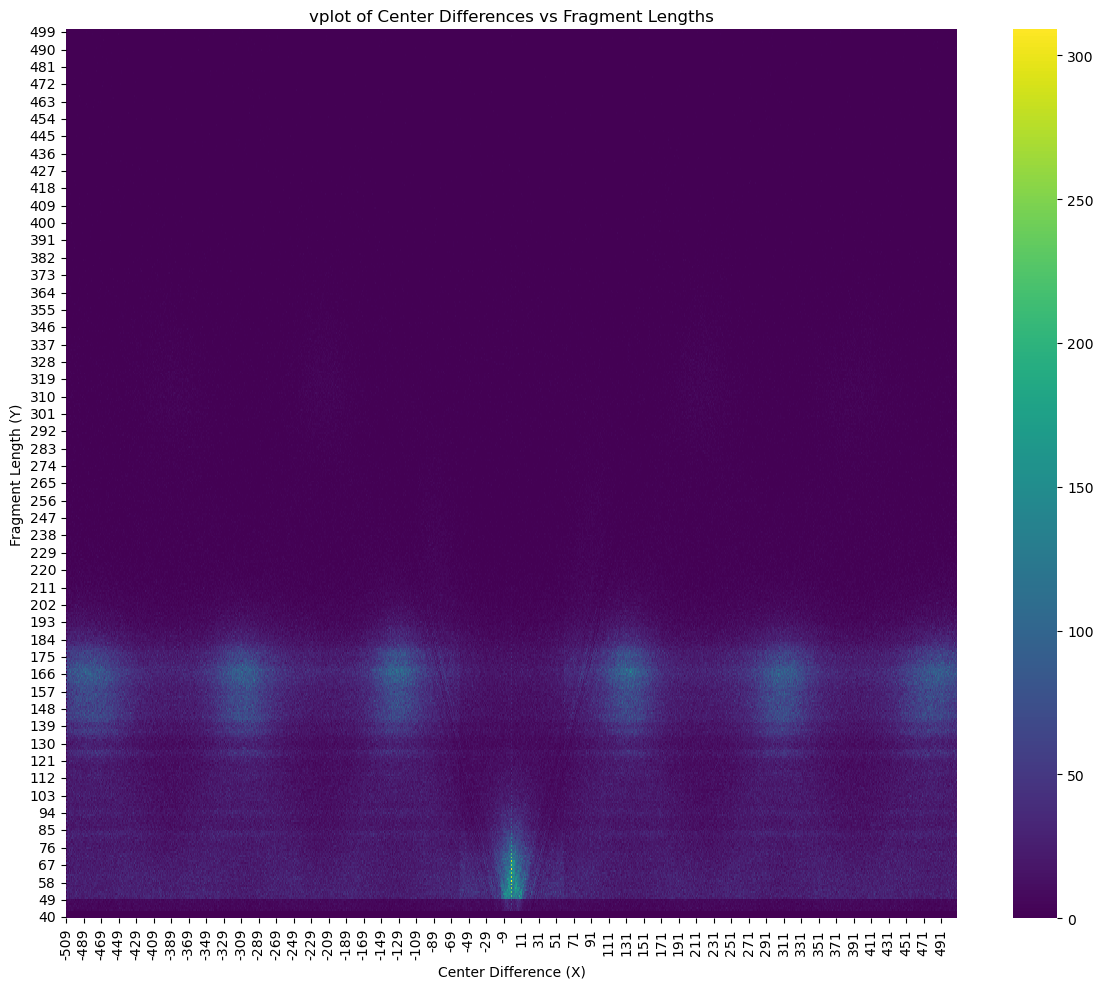

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Initialize counter to track frequency of (center_diff, fragment_len) pairs
pair_frequency = Counter()

# Read the BED-like file and process line-by-line
with open('mapped.bed', 'r') as file:
    for line in file:
        fields = line.strip().split('\t')

        # Calculate the centers of two intervals
        center_a = (int(fields[2]) + int(fields[3])) / 2
        center_b = (int(fields[8]) + int(fields[9])) / 2

        # Define X = difference of centers, Y = fragment length
        center_diff = int(center_b - center_a)
        fragment_len = int(fields[9]) - int(fields[8])

        # Update the frequency counter
        pair_frequency[(center_diff, fragment_len)] += 1

# Summary output
print("Total unique (X, Y) coordinate pairs found:", len(pair_frequency))

# Extract unique X and Y values
unique_x = sorted({x for x, _ in pair_frequency})
unique_y = sorted({y for _, y in pair_frequency})

# Build a 2D matrix to hold counts
heatmap_array = np.zeros((len(unique_y), len(unique_x)), dtype=int)
for y_idx, y_val in enumerate(unique_y):
    for x_idx, x_val in enumerate(unique_x):
        heatmap_array[y_idx, x_idx] = pair_frequency.get((x_val, y_val), 0)

# Convert to DataFrame for visualization
heatmap_df = pd.DataFrame(heatmap_array, index=unique_y, columns=unique_x)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_df, cmap='viridis', annot=False, fmt='d')
plt.gca().invert_yaxis()
plt.title('vplot of Center Differences vs Fragment Lengths')
plt.xlabel('Center Difference (X)')
plt.ylabel('Fragment Length (Y)')
plt.tight_layout()
plt.show()
